# Laboratory Day 10: Object Detection (YOLO V1)

In this exercise, we will implement and train a simplified version of YOLO_v1 network for object detection task.


## 1. Data preparation (40 points)
**Exercise 1.1 (20 points)**:
1. Download the dataset VOC_2007 from http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar

2. Download the file "2007_train.txt" and "2007_val.txt" from Moodle. These two files contain the image names, the positions of bounding boxes and the classes of bounding boxes for training and validation, respectively. 

    - For example, the second line in "2007_train.txt" is "VOCdevkit/VOC2007/JPEGImages/000017.jpg 185,62,279,199,14 90,78,403,336,12". It means that image 000017.jpg has two bounding boxes. The first one has coordinate (x_min, y_min, x_max, y_max) = (185,62,279,199) and class 14. The second bounding box has coordinate (90,78,403,336) and class 12. It is possible that an image has multiple bounding boxes.

    - The meaning of class ID is shown in the below. In total, we aim to recognize 20 classes.

3. Input $x$ of the original Yolo V1 network is of dimension 448\*448\*3. To make it compatible with VGG16 network (an following-up Exercise 2), we reduce the input dimension to 224\*224\*3. Furthermore, to simply the task, we take the number of predicted bounding boxes at each position $B=1$ in this exercise. Therefore, the output tensor $y$ of the network has dimension 7\*7\*25.

    - The first 20 positions in $y[:, :, :20]$ refer to the possibilities of each classes. The 21-th position $y[:, :, 20]$ refers to the confidence level $c$ and the last 4 positions $y[:, :, 21:25]$ refer to the object's location $x$, $y$, $w$, $h$.

    - Example: Take image "17.jpg" as an example. This image has (height, width)=(364, 480). The first bounding box is (90,78,403,336) and is of class 12. The middle point of this bounding box is (x_m, y_m) = (246, 207).  Patch's width = 480/7 = 68.5, patch's hight = 364/7= 52. Because $246/68.5=3.58$, $207/52=3.98$, the (4,4)-th patch is responsible for predicting this bbox. Therefore, $y[4, 4, 20:25] = [1.(\text{confidence}), 0.98 (\text{y-axis of image}), 0.58 (\text{x-axis of image}), (403-90)/480 (\text{relative width}), (336-78)/364 (\text{relative height})]$ is the encoded regression targets. $y[4, 4, :20]=[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0]$ is the classification target. The rest positions of $y$ are set to zero.

    - Note that, since we only have a single bounding box predictions for each cell (B=1). It is possible that multiple GT bounding boxes can belong to a single cell. In this case, we can not encode all of these bounding boxes into $y$. One could just ignore the rest bounding boxes in this case.

4. Write a date_generator function, which iterates through the dataset and yields image (np.ndarray, im_w\*im_h\*3) and GT tensor $y$ (np.ndarray, 7\*7\*25).

6. Print out several images and the locations of their bounding boxes.

7. Print out the non-zero positions of encoded tensor $y$

8. Optional: Make sure the GT tensors are correctly created. One can convert GT tensors $y$ to the original coordinates of bounding boxes and visualize them.

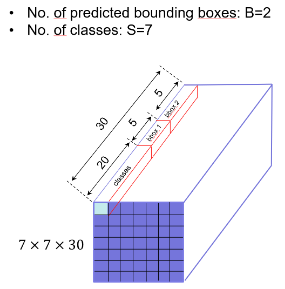




In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [ ]:
classes_id = {'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5,
               'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11,
               'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16,
               'sofa': 17, 'train': 18, 'tvmonitor': 19}

In [ ]:
# Solution
def data_generator(gt_file = "2007_train.txt"):
    # todo
    yield image, y
      


**Exercise 1.2 (20 points)** Data pipeline:
1. Build a data pipeline for the training data. 
    - Add distortions to the training data, e.g. adding random noises, applying Gaussian bluring. 
    - Apply tf.data.Dataset.from_generator(.) to load the training data. Please apply the following operation: (a) repeat the dataset (b) shuffle the dataset (c) resize the image to $224*244 *3$ (d) make up batches
    - The training dataset is repeated. So we can train the network for any number of steps.

  
2. Build a data pipeline for the validation data. 
    - apply no distortions or data augmentation operations
    - Apply tf.data.Dataset.from_generator(.) to load the validation data. For validation dataset, please apply the following operations: (a) resize the image to $224 *244 *3$ (b) make up batches.
    - The validation dataset is not repeated. Therfore, the for-loop knows where the dataset ends. 

3. Test that the image and GT tensors can be retrieved from data pipeline. 

4. Please visualize several examples and plot the bounding boxes in these images. A visualization example looks like this:  

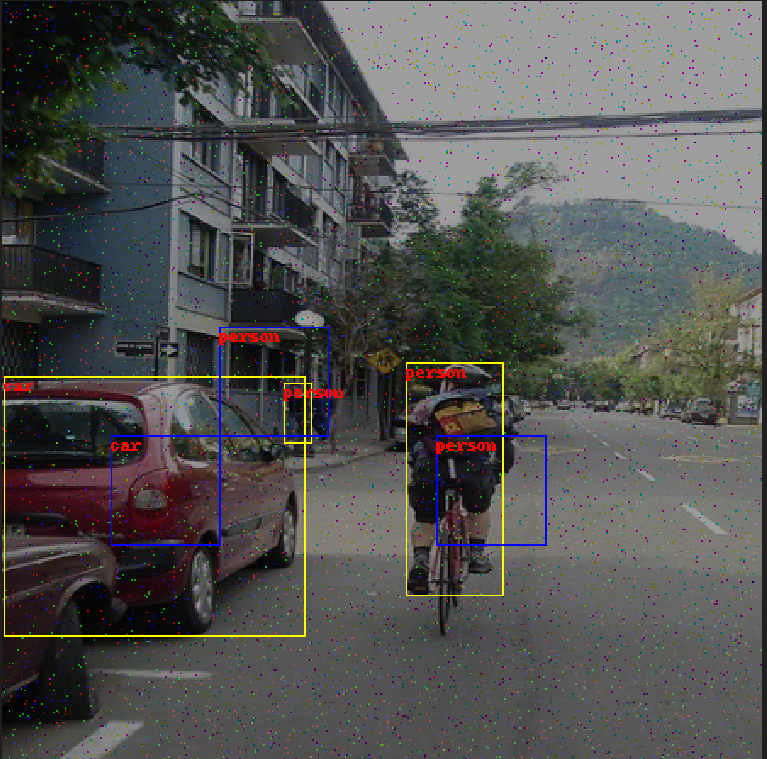

The yellow rectangular visualizes the locations of the GT bounding boxes. The blue rectangulars visualize the corresponding "grid cells", which are resposible for predicting bounding boxes. 

In [ ]:
# Solution


## 2. Modeling and Training (40 points)
**Exercise 2.1 (10 points)**

YOLO V1 network is not trained from scratch. Pretaining step and fine-tuning step are combined sequentially to train the entire YOLO network in the literature. This procedure contains the following steps:

1. Take a network, e.g. VGG16, ResNet34, which is already trained on a given data set (usually a large data set). Here, we take VGG16 network. 
2. Take the backbone of VGG16 network and fix all of its parameters. 
3. Add a head to the backbone. The head contains only convolutions. Now the backbone and the head constitute a YOLO network. The parameters of the head are trainable. 
4. Train the parameters of the head, while keep the parameters of the backbone fixed.  

Tasks: 
1. Call tf.keras.applications.vgg16.VGG16() to download a pretrained backbone of VGG16 on data set "imagenet". 

    - The input dimension of the backbone is $224*224*3$. The output dimension is $7*7*M$. 

2. Fix all trainable parameters of the backbone.

3. Add a head to the backbone. Make sure that the output of heads has dimension 7\*7\*25. As an option, one could use the following structure for the head:  

    - (1) conv, filters= 512, kernel 3\*3, activation='leaky_relu'

    - (2) conv, filters= 512, kernel 3\*3, activation='leaky_relu'

    - (3) conv, filters= ?, kernel 3\*3, activation='?'. The type of the activation should be selected such that all elements of the output tensor belong to [0, 1].  

4. create the model and print out model.summary()




In [ ]:
#  code sample. Feel free to change it
from keras.layers import Conv2D, MaxPooling2D, Input
from keras.models import Model

def modeling(img_h, img_w, img_c, num_class):
    x_input = Input(shape=(img_h, img_w, img_c))
    
    # todo: backbone
    
    backbone = tf.keras.applications.vgg16.VGG16(weights='imagenet', ...)
    x = backbone(x_input)
    
    # todo: fix parameters of backbone
    
    # todo: add head

    # modeling
    model = Model(inputs=x_input, outputs=y)
    model.summary()

    return model

**Exercise 2.2 Loss function (10 points)**
1. Please implement this loss function. $\lambda _{coord}$ = 100,  $\lambda _{noobj}=1$, shown in the lecture slide. For debugging purpose (optional), it is recommended to return the 3 parts of the loss function separately, namely loss_for_xywh, loss_for_confidence, loss_for_class.

2. For the following y_gt and y_pred, please compute the value of this loss function (to check the correctness of your implementation).
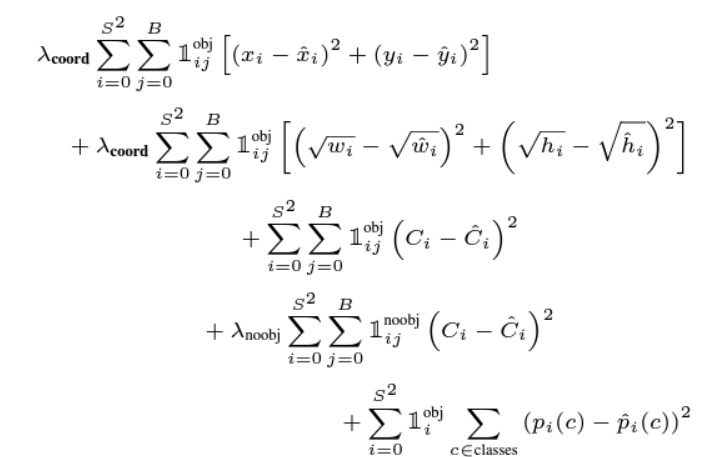

In [ ]:
import numpy as np
y_pred = np.ones((7, 7, 25)) * 0.5    

y_gt = np.zeros((7, 7, 25), dtype=np.float32)
y_gt[1, 1, :11] = 1
y_gt[1, 1, 20:25] = [1., 0.758, 0.95, (403-90)/480, (336-78)/364]

def loss_fun(y_pred, y_gt):
        pass

**Exercise 2.3 Training (20 points)**:
We have built all important elements of a training program for YOLO. Now let us combine them together to obtain a complete training program.

Tasks:
1. Write a training program to train YOLO model for in total $N$ steps. Choose the proper learning rate such that the loss function can be effectively reduced.

2. For each 100 training steps,

    - Print out (a) the average loss function for the last 100 steps.

    - Please print all string-based info into a txt file. It is recommended to use logging package (see below).

3. After the entire training is finished, evaluate the average loss function on val data (2007_val.txt).

4. Check the values of non-trainable variables of the VGG16 backbone. Their values should be kept the same during the training process. An easy way is to check the summation of non-trainable variables by calling sum_of_vars(model.non_trainable_variables).

Advice:
    YOLO V1 is not a trivial system, and training it is complicated. Any mistakes in the data pipeline, in the modeling and in the selection of training parameters may lead to undesired training results. To debug the training process, my suggestions:

1. Visualize the images ($224*224*3$) that are fed directly to network.

2. Visualize the output tensor by visualizing the decoded bounding boxes. Step 1 and 2 make sure that the network gets the correct "data".

3. Obverse the loss function for its three sub-parts, separately. If some parts do not get reduced, find out the reason.

4. Adjust the learning rate.

5. Check the transformation between output tensor and the bouding box label. It is often that this encoding-decoding process is wrong.

6. If over-fitting, try to reduce the model complexity or do early stoping.

In [ ]:
# functions, which could be used (optional)
import logging
def init_logging(log_path=None, mode='w', level=logging.INFO):
    if not log_path:
        log_path = os.path.join(os.getcwd(), 'filename.log')
    if level is None:
        level = logging.INFO
    format = '%(asctime)s - %(name)s - %(levelname)s : %(message)s'
    handlers = [logging.FileHandler(log_path, mode=mode), logging.StreamHandler()]
    logging.basicConfig(level=level, format=format, handlers=handlers)
    logging.info(f'log_path: {log_path}')


def sum_of_vars(var):
    # var = model.trainable_variables or model.non_trainable_variables
    value = 0
    num = 0
    for t in var:
        value += np.sum(t.numpy())
        num += np.prod(t.shape.as_list())

    return value, num

In [ ]:
# Solution example. Feel free to change it
import logging
import tensorflow as tf
import numpy as np

work_dir = r'' 

# logging
logging_path = os.path.join(work_dir, 'logging.log')
init_logging(logging_path, level=logging.DEBUG)
logger = logging.getLogger(__name__)


class YOLOModel(tf.keras.Model):
    def __init__(self, work_dir):
        super().__init__()
        self.input_w = 224
        self.input_h = 224
        self.input_c = 3
        self.num_class = 20

        self._setup_layers()
        self._setup_metrics()
         
        self.work_dir = work_dir

    @property
    def metrics(self):
        return [self._loss_metric, self._loss_metric_existence, self._loss_metric_xywh, self._loss_metric_class]

    def _setup_metrics(self):
        self._loss_metric = tf.keras.metrics.Mean(name='loss_mean')
        self._loss_metric_existence = tf.keras.metrics.Mean(name='loss_mean_existence')
        self._loss_metric_xywh = tf.keras.metrics.Mean(name='loss_mean_xywh')
        self._loss_metric_class = tf.keras.metrics.Mean(name='loss_mean_class')

    def _metrics_reset(self):
        for m in self.metrics:
            m.reset_states()

    def _update_metrics(self, loss, loss_obj_existence, loss_xywh, loss_class):
        self._loss_metric.update_state(loss)
        self._loss_metric_existence.update_state(loss_obj_existence)
        self._loss_metric_xywh.update_state(loss_xywh)
        self._loss_metric_class.update_state(loss_class)

   
    def _setup_layers(self):
        self.cnn = modeling(...)     

    def train(self, data_train, steps, delta_steps=100):
        for step, (image, y_label) in enumerate(data_train):
            # compute loss and update gradients
            # todo

            # update metrics
            self._update_metrics(loss, loss_obj_existence, loss_xywh, loss_class)
          
            if step % delta_steps == 0:
                self._metrics_reset()
                self._data_visualize() #optional: only for debug
                self._savemodel()
                
                
            if step >= steps:
                break

        print(f'done: total_step {step}, finish')


    def loss_fun(self, y_pred, y_label):
        # re-use the code in e3.1
        raise NotImplemented

    def data_visualize(self, data):
        raise NotImplemented

    def save_model():
        raise NotImplemented

    def load_model():
        raise NotImplemented


**Exercise 2.4 NMS and Prediction (Not mandatory, 10 points)**:
The predictions of YOLO model may contain multiple bounding boxes for the same object in the image. Non-Maximum Suppression (NMS) is a method to clean up redundant bounding boxes by checking Intersection over Union (IoU). 

Tasks: 
1. Please implement or call any NMS algorithm. The algorithm takes the positions of bounding boxes, their confidences and an IoU threshold. It outputs the positions of bounding boxes after clean-up.

2. Please test the developed NMS algorithm on the prediction of any selected image, which is not seen by the network. 

3. Visualize the predicted bounding boxes with and without NMS.

In [ ]:
def non_max_suppression(bb_labels, bb_confidences, iou_threshold):
    pass 

# prediciton
y = yolo_model(image, training=False)

